In [4]:
!pip install openpyxl

In [5]:
import pandas as pd

In [ ]:

# 엑셀 파일 읽기
# df = pd.read_excel(f'C:/Users/CEO/ton/project/data/raw/소비자심리지수.xlsx')  # 예: 'data.xlsx'

# CSV 파일로 저장
# df.to_csv(f'C:/Users/CEO/ton/project/data/raw/소비자심리지수.csv', index=False)  # 예: 'data.csv'

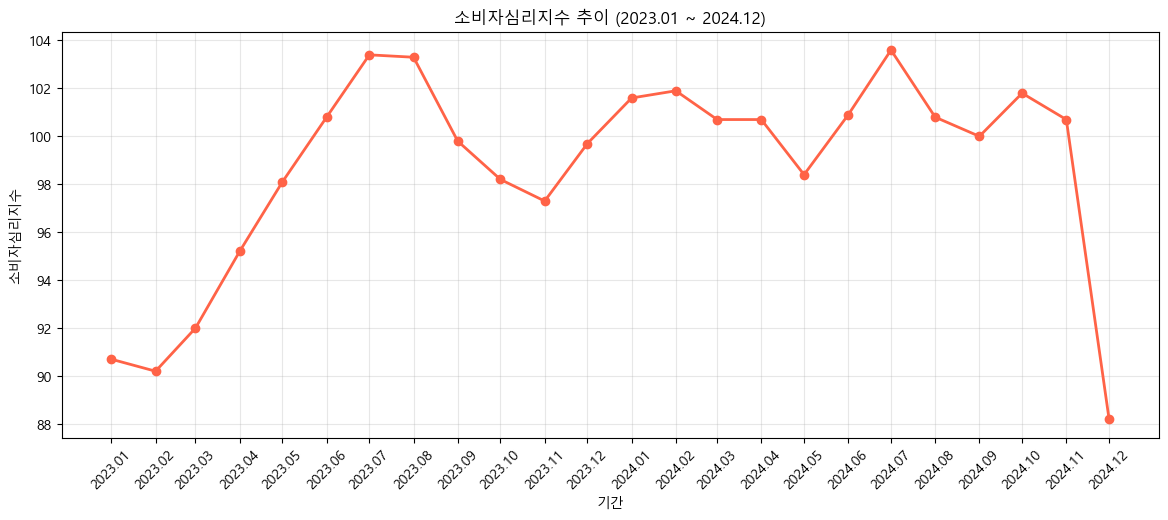

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc
import platform, re

if platform.system() == 'Windows':
    rc('font', family=font_manager.FontProperties(fname="c:/Windows/Fonts/malgun.ttf").get_name())
elif platform.system() == 'Darwin':
    rc('font', family='AppleGothic')
else:
    rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

path = r'C:/Users/CEO/ton/project/data/raw/소비자심리지수.csv'
raw = pd.read_csv(path, encoding='utf-8-sig', header=None)


raw.columns = raw.iloc[0, :].astype(str)
raw = raw.drop(0).reset_index(drop=True)

cleaned = []
for c in raw.columns:
    cname = str(c).strip().replace('\ufeff', '')  # BOM 제거
    cname = re.sub(r'[^0-9]', '', cname)          # 숫자만 남기기
    if len(cname) == 6 and cname.startswith("20"):  # '202301' 같은 6자리
        cleaned.append(cname)

raw.columns = [re.sub(r'[^0-9]', '', str(c)).strip().replace('\ufeff', '') for c in raw.columns]

df = raw.loc[:, [c for c in raw.columns if c in cleaned]]

series = df.iloc[0]
series.index = pd.to_datetime(series.index, format="%Y%m")
series = series.astype(float)

plt.figure(figsize=(12,5))
plt.plot(series.index, series.values, marker='o', color='tomato', linewidth=2)

plt.title("소비자심리지수 추이 (2023.01 ~ 2024.12)")
plt.xlabel("기간")
plt.ylabel("소비자심리지수")
plt.grid(True, alpha=0.3)
plt.tight_layout()

# x축 표시 포맷
plt.xticks(series.index, [d.strftime("%Y.%m") for d in series.index], rotation=45)
plt.show()
